# PROYECTO FINAL APRENDIZAJE SUPERVISADO 2



# Datos del alumno

**Nombre**: Adrián


**Apellidos**: Robles Arques


**Grupo:** A1

FASE 2
---------------------------------

Recordamos que el objetivo de este proyecto es predecir si un trabajador va a abandonar la empresa o no (variable `left`).

El objetivo de este sprint es entrenar 3 árboles de decisión:


*   Uno sin aplicar ningún criterio de poda (sin hiperparámetros)
*   Otros dos especificando diferentes hiperparámetros.

Para este caso continuaremos con los datos empleados en secciones anteriores.

Lo primero de todo será importar las librerías necesarias.

In [1]:
import os
from google.colab import files
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             roc_auc_score,
                             roc_curve,
                             confusion_matrix,
                             classification_report,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     learning_curve,
                                     validation_curve,
                                     train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

%matplotlib inline

Y las específicas para este sprint.

In [2]:
##Si no habéis instalado previamente la librería, tenéis que descomentar la siguiente línea para descargar dtreeviz
!pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.2 MB/s eta 0:00:00


In [3]:
from sklearn import tree
import dtreeviz
from sklearn.tree import export_text

Cargamos las matrices de train y test que hemos calculado en el sprint 1.

In [4]:
##Descarga manual: https://drive.google.com/file/d/1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9/view?usp=sharing
##Descarga manual: https://drive.google.com/file/d/1O1BRGwSd81TOOpaQvoo5BHDsrPEruz93/view?usp=sharing
##Descarga manual: https://drive.google.com/file/d/1u3yI5L_2YI77uF_WT9ysIzw8dydVlQSh/view?usp=sharing
##Descarga manual: https://drive.google.com/file/d/1eWo_m2gbihSuUQeOhH8I8Q0uudluQKBT/view?usp=sharing

#Descargamos los ficheros de Google Drive (si lo ejecutais en un entorno diferente a Google Colab, tenéis que intalar previamente wget en vuestro PC)
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9' -O 'y_train.npy'
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1O1BRGwSd81TOOpaQvoo5BHDsrPEruz93' -O 'y_test.npy'
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1u3yI5L_2YI77uF_WT9ysIzw8dydVlQSh' -O 'X_train.npy'
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1eWo_m2gbihSuUQeOhH8I8Q0uudluQKBT' -O 'X_test.npy'

In [5]:
#Cargamos desde local los datos previos
uploaded = {}
uploaded = files.upload()
X_train = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
X_test = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
y_train = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
y_test = np.load(list(uploaded.keys())[0])

Saving X_train.npy to X_train.npy


Saving X_test.npy to X_test.npy


Saving y_train.npy to y_train.npy


Saving y_test.npy to y_test.npy


Verificamos que las dimensiones se corresponden con la partición de 80% de los datos para el conjunto de train y 20% de los datos para test.

In [6]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(11999, 18)
(3000, 18)
(11999,)
(3000,)


In [7]:
#Cargar datos de las columnas desde PC
uploaded = {}
uploaded = files.upload()
columnas = uploaded[list(uploaded.keys())[0]]

Saving nom_columnas.txt to nom_columnas.txt


In [8]:
#Generando la lista de nombres de columnas
nom_columnas = columnas.decode('utf-8').split('\n')
nom_columnas = nom_columnas[:-1] #Aparece un espacio al final
left_ind = nom_columnas.index('left')

#Eliminamos left, dado que es la variable objetivo
nom_columnas = nom_columnas[:left_ind] + nom_columnas[left_ind+1:]
nom_columnas

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years',
 'salary',
 'dep_IT',
 'dep_RandD',
 'dep_accounting',
 'dep_hr',
 'dep_management',
 'dep_marketing',
 'dep_product_mng',
 'dep_sales',
 'dep_support',
 'dep_technical']

# CUESTION 1 - Árbol con hiperparámetros por defecto

In [9]:
# Generamos un árbol de decisión para clasificación
clf_tree = tree.DecisionTreeClassifier(class_weight="balanced")

# El parámetro class_weight='balanced' emplea los valores de y para ajustar automáticamente los pesos de forma inversamente proporcional a la frecuencia de cada clase en el input

In [10]:
# Entrenamos el modelo con los datos de entrenamiento
clf_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [11]:
# Obtenemos las predicciones para el conjunto de test
Y_pred = clf_tree.predict(X_test)
Y_pred_proba = clf_tree.predict_proba(X_test)

#Predicciones para el conjunto de entrenamiento
Y_pred_train = clf_tree.predict(X_train)
Y_pred_proba_train = clf_tree.predict_proba(X_train)

In [12]:
# ¿Cual es la profundidad del árbol entrenado?
clf_tree.get_depth()

21

<Figure size 1000x1000 with 0 Axes>

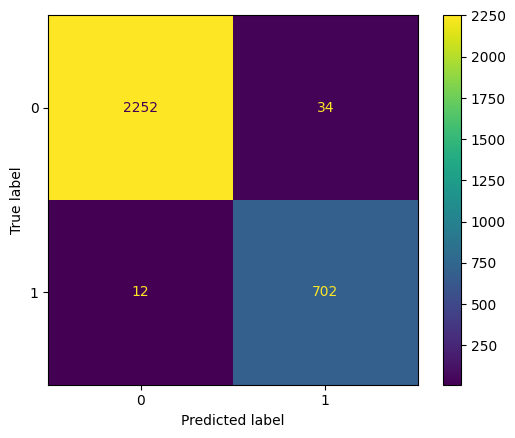

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.95      0.98      0.97       714

    accuracy                           0.98      3000
   macro avg       0.97      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



Text(0.5, 1.0, 'Curva ROC')

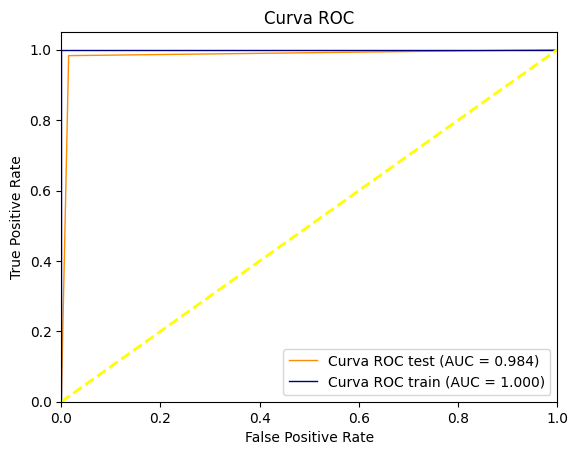

In [13]:
# Evaluar la capacidad predictiva del modelo
cm_tree = confusion_matrix(y_test, Y_pred)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_tree)
ax.plot()
plt.show()

report1 = classification_report(y_test, Y_pred, digits = 2)
print(report1)

#Generamos la curva ROC y calculamos el área bajo la curva
fpr_test, tpr_test, thresholds = roc_curve(y_test, Y_pred_proba[:,1])
roc_auc_test = roc_auc_score(y_test, Y_pred_proba[:,1])

fpr_train, tpr_train, thresholds = roc_curve(y_train, Y_pred_proba_train[:,1])
roc_auc_train = roc_auc_score(y_train, Y_pred_proba_train[:,1])

plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', lw=1, label='Curva ROC test (AUC = %0.3f)' % roc_auc_test)
plt.plot(fpr_train, tpr_train, color='navy', lw=1, label='Curva ROC train (AUC = %0.3f)' % roc_auc_train)
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], color='yellow', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')

In [14]:
#Visualizamos el arbol
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_tree_np = StringIO()
export_graphviz(clf_tree, out_file= dot_tree_np,
                filled=True, rounded=True,
                special_characters=True, feature_names = nom_columnas ,class_names=['stays','leaves'])
graph = pydotplus.graph_from_dot_data(dot_tree_np.getvalue())
graph.write_png('Empresa.png')
Image(graph.create_png())

Este arbol obtiene unos resultados extremadamente buenos, tanto en el conjunto de entrenamiento como el de test, aunque da la impresión de estar sobreentrenado al obtener un AUC de 1 para el conjunto de entrenamiento, pero no dista demasiado del AUC final para el conjunto de test.

La precisión es de 0.99/0.95, la exactitud de 0.98, lo que nos da un f-1 total de 0.99/0.97, un gran resultado. Sin embargo el cliente quería un modelo fácilmente entendible por un humano, y este no es el caso. Con una profundidad máxima de 21, y atendiendo a su representación gráfica, vemos una serie de ramificaciones tan enorme que es muy dificil de seguir para una persona.

Por tanto, a pesar de obtener unos resultados tanto en la matriz de confusión como en la curva ROC, el AUC y el F1 mejor que para el caso del modelo KNN que contruimos en el anterior sprint, este modelo tampoco se ajustaría a lo demandado por el cliente.

# CUESTION 2 - Árbol modificando algún hiperparámetro

Sugerencia: ¿Qué ocurre si limitamos la profundidad del árbol?

In [15]:
#Vamos a evaluar diferentes niveles de profundidad y encontrar la mejor opción
param_grid = {'max_depth': range(1,6), 'min_samples_split': range(3,20) , 'min_samples_leaf': range(1,11),
               'class_weight' : ['balanced']}

tree_2 = GridSearchCV(tree.DecisionTreeClassifier(), param_grid,
                            return_train_score= True,
                            cv= 5, scoring= 'f1')

#Entrenamos el modelo
tree_2.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': ['balanced'], 'max_depth': range(1, 6),
                         'min_samples_leaf': range(1, 11),
                         'min_samples_split': range(3, 20)},
             return_train_score=True, scoring='f1')

In [16]:
#Predicciones para el conjunto de test
Y_pred2 = tree_2.predict(X_test)
Y_pred_proba2 = tree_2.predict_proba(X_test)

#Predicciones conjunto de entrenamiento
Y_pred_train2 = tree_2.predict(X_train)
Y_pred_proba_train2 = tree_2.predict_proba(X_train)

<Figure size 1000x1000 with 0 Axes>

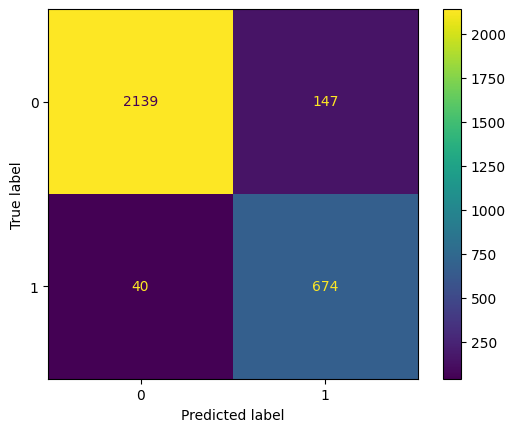

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      2286
           1       0.82      0.94      0.88       714

    accuracy                           0.94      3000
   macro avg       0.90      0.94      0.92      3000
weighted avg       0.94      0.94      0.94      3000



Text(0.5, 1.0, 'Curva ROC')

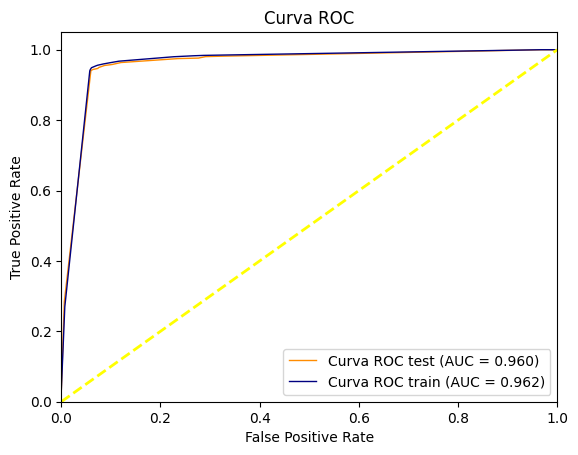

In [17]:
# Evaluar la capacidad predictiva del modelo
cm_tree2 = confusion_matrix(y_test, Y_pred2)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_tree2)
ax.plot()
plt.show()

report2 = classification_report(y_test, Y_pred2)
print(report2)

#Generamos la curva ROC y calculamos el área bajo la curva
fpr_test, tpr_test, thresholds = roc_curve(y_test, Y_pred_proba2[:,1])
roc_auc_test = roc_auc_score(y_test, Y_pred_proba2[:,1])

fpr_train, tpr_train, thresholds = roc_curve(y_train, Y_pred_proba_train2[:,1])
roc_auc_train = roc_auc_score(y_train, Y_pred_proba_train2[:,1])

plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', lw=1, label='Curva ROC test (AUC = %0.3f)' % roc_auc_test)
plt.plot(fpr_train, tpr_train, color='navy', lw=1, label='Curva ROC train (AUC = %0.3f)' % roc_auc_train)
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], color='Yellow', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')

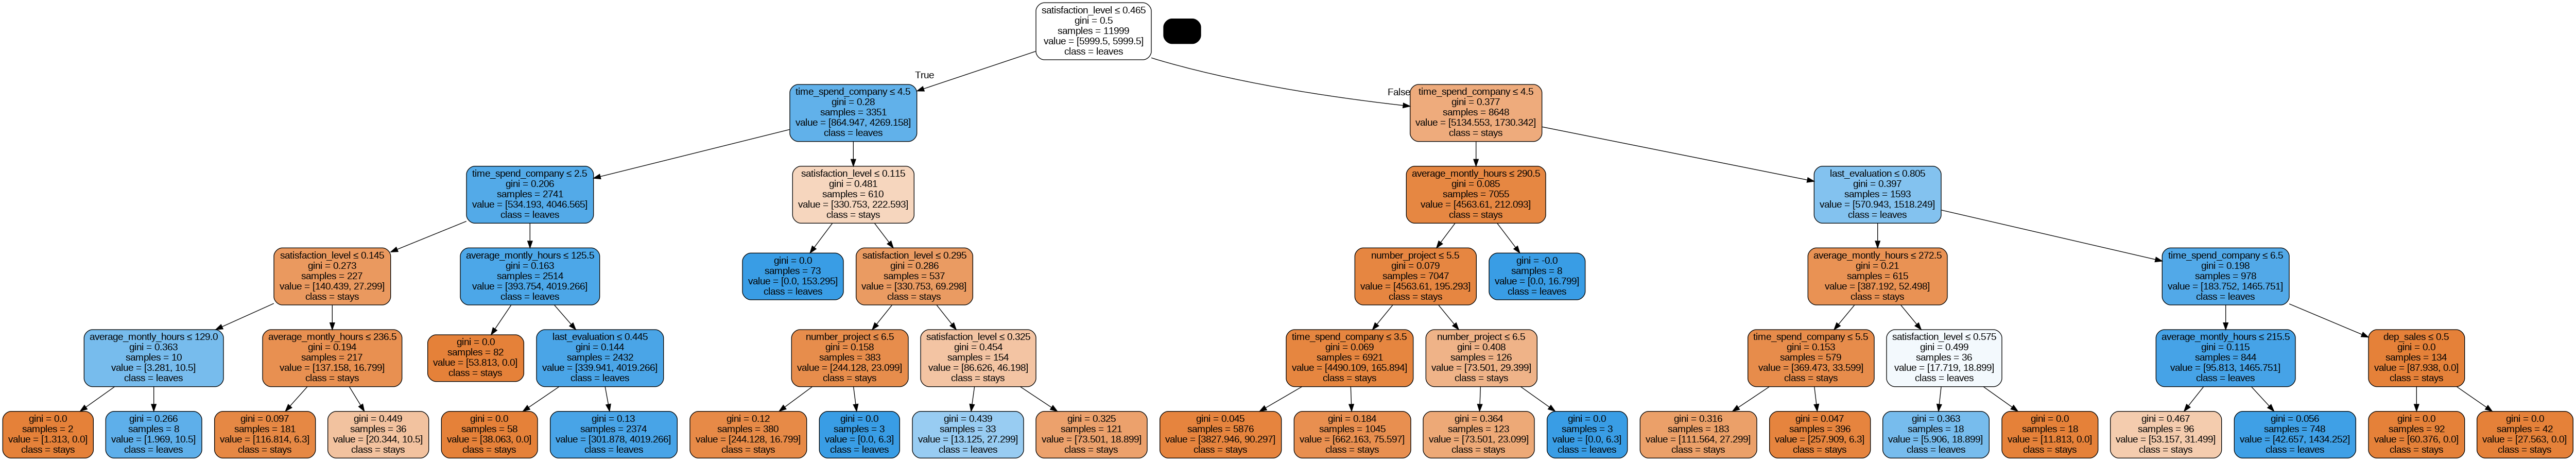

In [18]:
#Visualizamos el arbol
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_tree_np = StringIO()
export_graphviz(tree_2.best_estimator_, out_file= dot_tree_np,
                filled=True, rounded=True,
                special_characters=True, feature_names = nom_columnas ,class_names=['stays','leaves'])
graph = pydotplus.graph_from_dot_data(dot_tree_np.getvalue())
graph.write_png('Empresa.png')
Image(graph.create_png())

# CUESTION 3 - Árbol modificando algún hiperparámetro

Sugerencia: ¿Y si cambiamos el criterio para evaluar la impureza de las particiones?

In [19]:
#Vamos a evaluar diferentes niveles de profundidad y encontrar la mejor opción
param_grid_2 = {'max_depth': range(1,6), 'min_samples_split': range(3,20) , 'min_samples_leaf': range(1,11),
               'class_weight' : ['balanced'], 'criterion':['entropy','log_loss']}

tree_3 = GridSearchCV(tree.DecisionTreeClassifier(), param_grid_2,
                            return_train_score= True,
                            cv= 5, scoring= 'roc_auc')

#Entrenamos el modelo
tree_3.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': ['balanced'],
                         'criterion': ['entropy', 'log_loss'],
                         'max_depth': range(1, 6),
                         'min_samples_leaf': range(1, 11),
                         'min_samples_split': range(3, 20)},
             return_train_score=True, scoring='roc_auc')

In [20]:
#Predicciones para el conjunto de test
Y_pred3 = tree_3.predict(X_test)
Y_pred_proba3 = tree_3.predict_proba(X_test)

#Predicciones para el conjunto de entrenamiento
Y_pred_train3 = tree_3.predict(X_train)
Y_pred_proba_train3 = tree_3.predict_proba(X_train)

<Figure size 1000x1000 with 0 Axes>

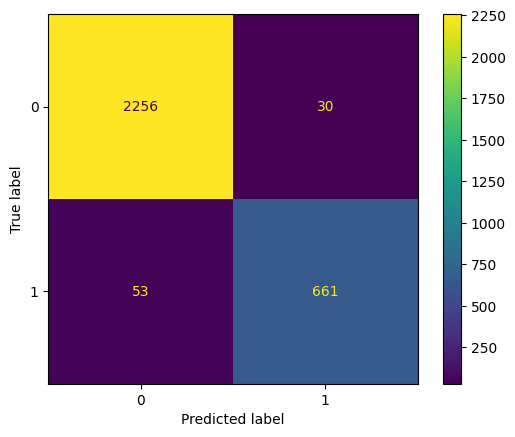

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2286
           1       0.96      0.93      0.94       714

    accuracy                           0.97      3000
   macro avg       0.97      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000



Text(0.5, 1.0, 'Curva ROC')

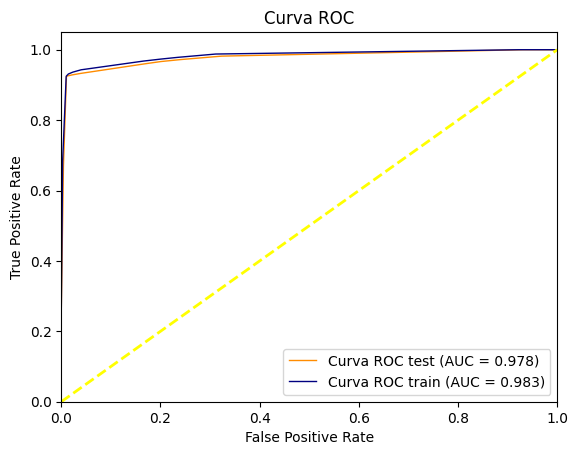

In [21]:
# Evaluar la capacidad predictiva del modelo
cm_tree3 = confusion_matrix(y_test, Y_pred3)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_tree3)
ax.plot()
plt.show()

report3 = classification_report(y_test, Y_pred3)
print(report3)

#Generamos la curva ROC y calculamos el área bajo la curva
fpr_test, tpr_test, thresholds = roc_curve(y_test, Y_pred_proba3[:,1])
roc_auc_test = roc_auc_score(y_test, Y_pred_proba3[:,1])

fpr_train, tpr_train, thresholds = roc_curve(y_train, Y_pred_proba_train3[:,1])
roc_auc_train = roc_auc_score(y_train, Y_pred_proba_train3[:,1])

plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', lw=1, label='Curva ROC test (AUC = %0.3f)' % roc_auc_test)
plt.plot(fpr_train, tpr_train, color='navy', lw=1, label='Curva ROC train (AUC = %0.3f)' % roc_auc_train)
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], color='Yellow', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')

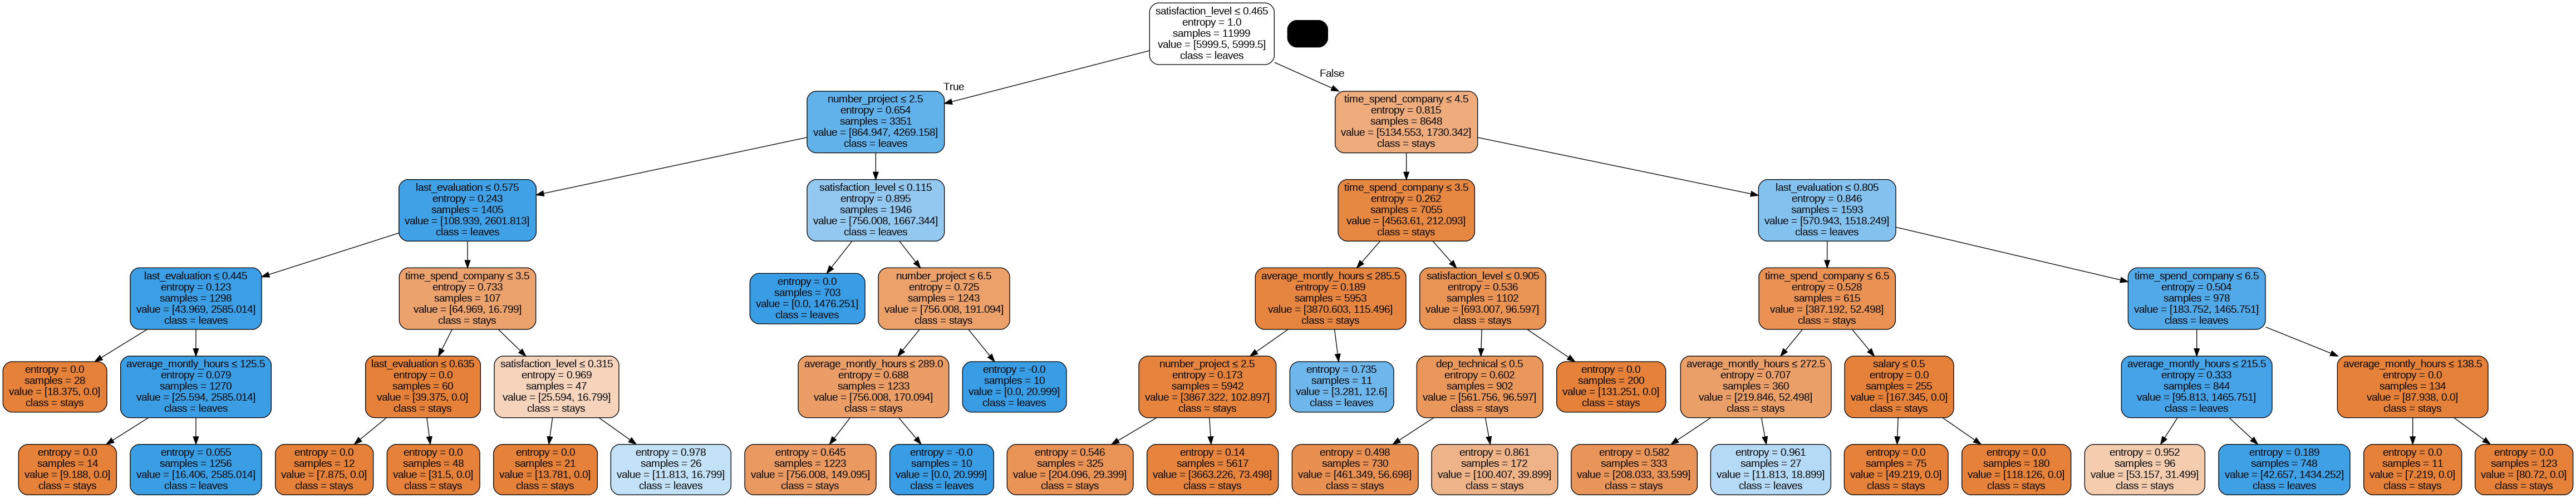

In [22]:
#Visualizamos el arbol
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_tree_np = StringIO()
export_graphviz(tree_3.best_estimator_, out_file= dot_tree_np,
                filled=True, rounded=True,
                special_characters=True, feature_names = nom_columnas ,class_names=['stays','leaves'])
graph = pydotplus.graph_from_dot_data(dot_tree_np.getvalue())
graph.write_png('Empresa.png')
Image(graph.create_png())

# CUESTION 4 - ¿Qué modelo tiene mayor poder predictivo?

Comparar los diferentes árboles entrenados empleando las métricas más adecuadas para un problema desbalanceado como el nuestro.

In [23]:
eval1 = pd.DataFrame(classification_report(y_test, Y_pred, output_dict=True)).transpose()
eval2 = pd.DataFrame(classification_report(y_test, Y_pred2, output_dict=True)).transpose()
eval3 = pd.DataFrame(classification_report(y_test, Y_pred3, output_dict=True)).transpose()

In [24]:
eval1

,precision,recall,f1-score,support
0,0.994700,0.985127,0.989890,2286.000000
1,0.953804,0.983193,0.968276,714.000000
accuracy,0.984667,0.984667,0.984667,0.984667
macro avg,0.974252,0.984160,0.979083,3000.000000
weighted avg,0.984967,0.984667,0.984746,3000.000000


In [26]:
for i in [eval1, eval2, eval3]:
    print('f1-score 1 = ', round(i['f1-score']['1'],5))
    print('f1-score 0 = ', round(i['f1-score']['0'],5))

f1-score 1 =  0.96828
f1-score 0 =  0.98989
f1-score 1 =  0.87818
f1-score 0 =  0.95812
f1-score 1 =  0.94093
f1-score 0 =  0.98194


In [27]:
tree_3.best_estimator_

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_leaf=10, min_samples_split=3)

Dado que tenemos un problema desbalanceado, la precisión del resultado '1' o 'leaves', es decir, que la persona se marcha de la empresa, es altamente sensible a pequeños cambios en el conjunto de testeo, dado que los casos totales de este resultado son muy inferiores al otro valor posible, '0' o 'stays'.

Por lo tanto este será nuestro principal valor predictor para el modelo, la precisión del caso '1', como otros predictores emplearemos el 'f1-score' para el caso '0', y el área bajo la curva ROC. Accuracy no es un buen predictor para un caso desbalanceado como este.



*   Modelo 1:
  *  Precisión '1': 0.9525
  *  f1-score '0': 0.9897
  *  AUC ROC: 0.984

*   Modelo 2:
  * Precision '1': 0.8210
  * f1-score '0': 0.9581
  * AUC ROC: 0.960

* Modelo 3:
  * Precisión '1': 0.9566
  * f1-score '0': 0.9819
  * AUC ROC: 0.978


Comparados los resultados, optaremos por el modelo 3, dado que tiene mejores resultado evidentemente que el segundo modelo, con valores predictores aparentemente ligeramente inferiores al primero, pero unos parámetros que lo hacen más sencillo de interpretar por humanos, una de las características solicitadas, y además presenta un sobreajuste menor que el primer modelo.

## Comparación con el mejor modelo de la Fase 1

Al final de la fase anterior concluimos que el mejor modelo obtenido era el generado mediante el algoritmo KNN, que tenía la contrapartida de actuar como caja negra y donde le proceso de decisión no es interpretable por un humano. Sin embargo, podemos comparar los resultados entre el modelo de KNN con nuestro mejor árbol de decisión, y vemos lo siguiente:



*   Árbol de decisión:
  *  f-1 score 0: 0.98
  *  f-1 score 1: 0.94
  *  AUC test: 0.978
  *  AUC train: 0.983

*   K-nearest neighbours:
  * f-1 score 0: 0.96
  * f-1 score 1: 0.87
  * AUC test: 0.975
  * AUC train: 0.988

Por lo que, comparando las métricas y las matrices de confusión, podemos concluir que el árbol de decisión es superior en sus resultados al modelo KNN, mejorando especialmente al reducir el número de falsos positivos, reduciendo ligeramente también el overfitting.

Además, el modelo de árbol de decisión es más facilmente interpretable al ser legible el proceso de decisión íntegro. Además, por el funcionamiento del algoritmo, el modelo KNN es más complejo, dado que guarda todos los datos durante el entrenamiento y los procesa durante la fase de predicción para evaluar las distancias a cada punto.

# CUESTION 5 - Representación del árbol

En este apartado se valorará más la capacidad de analizar la información que nos transmite la representación visual y en formato literal ( [export_text()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html) ), que el propio gráfico en sí. Por lo tanto, si el árbol que has elegido es demasiado profundo, te recomiendo emplear para este apartado uno más simple, limitando la profundidad, para que la representación y análisis sea legible y entendible.

*NOTA*: las matrices de train y test que hemos cargado al inicio del sprint no contienen información de los nombres de cada atributo. Esto se puede solventar cargando de nuevo los datos con los que comenzábamos el sprint 1.

Recordad que en el sprint 1 para obtener las matrices de train y test, previamente realizamos unas transformaciones de los datos. Recordamos los pasos:



*   Renombrar la variable `sales` a `department`.
*   Recodificar la variable `salary` con el siguiente criterio para conservar el sentido de orden que contiene la variable: low=0, medium=1, high=2.
*   Transformar la otra variable de tipo *object* (`department`) a numérica codificando sus categorías como variables dummies.


Por lo tanto, a continuación os dejo un enlace para descargar el fichero original al que, para poder usarlo en este sprint, tendréis que hacer previamente las transformaciones descritas previamente.

In [ ]:
#Descarga manual: https://drive.google.com/file/d/1ZwgdmI525zInDh1SQVm7FZt8kWxfrvOK/view?usp=sharing
#Descargamos los ficheros de Google Drive
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1ZwgdmI525zInDh1SQVm7FZt8kWxfrvOK' -O 'Rotacion_empleados.csv'

Si no conseguís descargar el fichero con el anterior comando, también lo tenéis a vuestra disposición en los **Recursos del proyecto** con el nombre `Rotacion_empleados.csv`.

**NOTA PROCEDIMIENTO:** Para solventar esto, en lugar de cargar los datos desde Drive, he descargado inicialmente los datos obtenidos en el Sprint 1 y los he cargado desde local para utilizarlos en es sprint 2, incluyendo los datos de las columnas. La información ya está codificada de esta forma, con los dummies para los departamentos y el salario recodificado.

***NOTA 2***: Ya he realizado una primera aproximación visual en el apartado correspondiente a cada modelo, por tanto pasaré a emplear la representación gráfica de dtreeviz y evaluar el tercer modelo.

In [ ]:
#Configuramos el adaptador
viz = dtreeviz.model(tree_3.best_estimator_,
X_train,
y_train,
target_name='left',
feature_names= nom_columnas,
class_names={0:'stays', 1:'leaves'} # necesario class_names para el clasificador
)

#Llamamos al método para la visualización
viz.view(fontname='sans-serif')

Según podemos ver en el arbol de decisión, una de las primeras cosas que puede llamarnos la atención es que no ha empleado el departamento de origen en ningún momento para la toma de decisiones, salvo en el cuarto nivel y con ambos nodos hoja resultantes con la misma respuesta,  por lo que se entiende que la probabilidad de marcharse es independiente del departamento de procedencia, al menos según este modelo.

Vemos que el modelo toma como nodo raiz el nivel de satisfacción del empleado, lo cual tiene sentido con el análisis de variables realizado en el anterior sprint dado que era la variable explicativa con mayor correlación con la variable objetivo 'left'.

Tal como habíamos observado en el mejor modelo predictor dentro de los posibles parametros introducidos en el GridSearch, este árbol tiene una profundidad de 5 niveles, aunque encontramos el primer nodo hoja ya en el nivel 3, tras una segunda evaluación del nivel de satisfacción para empleados con muchos proyectos en curso.

Como resultado, los que más se marchan son, por un lado, los que tienen un nivel de satisfacción muy bajo y muchos proyectos `[Sat_lvl < 0.09, Num_proyect >= 3]`, o si tienen menos proyectos, aquellos cuya evaluación es moderada pero hacen un número significativo de horas `[Sat_lvl < 0.465, Num_pryect < 3, Last_eval > 0.445, Mntly_h > 125.5]`. El otro grupo que más se marcha son aquellos con buen nivel de satisfacción en la empresa, pero que desempeñan muchas horas en su puesto de trabajo y tienen un resultado en su evaluación notable o sobresaliente, sin llevar más de 7 años en la empresa `[Sat_lvl > 0.465, Lst_eval > 0.805, T_spend_c < 6.5, Mntly_h > 215.5 ]`.